# Exploratory Data Analysis: Sentiment140
This notebook analyzes the class distribution, tweet lengths, and linguistic features of the Sentiment140 dataset.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib style
plt.style.use('default')

from analytics.data_processing import (
    compute_class_distribution,
    compute_tweet_lengths,
    compute_log_odds_ratio,
    compute_temporal_features,
    compute_linguistic_features,
    summarize_linguistic_features
)

In [2]:
DATASET_PATH = '../dataset/sentiment140.csv'
df = pd.read_csv(DATASET_PATH, encoding='latin-1', header=None, names=['target', 'id', 'date', 'flag', 'user', 'text']).sample(50000, random_state=42)
df.head()

,target,id,date,flag,user,text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


## 1. Class Distribution

target
Positive    25014
Negative    24986
Name: count, dtype: int64


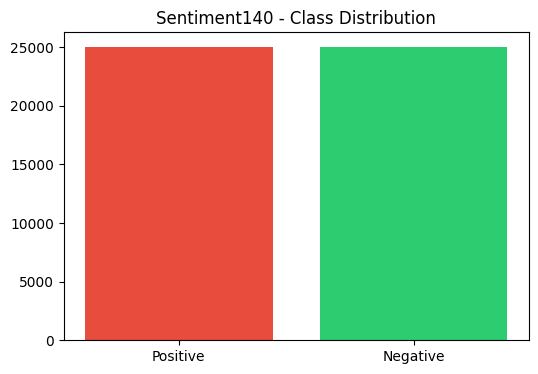

In [3]:
counts = compute_class_distribution(df)
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
ax.set_title('Sentiment140 - Class Distribution')
plt.show()

## 2. Tweet Length Distribution

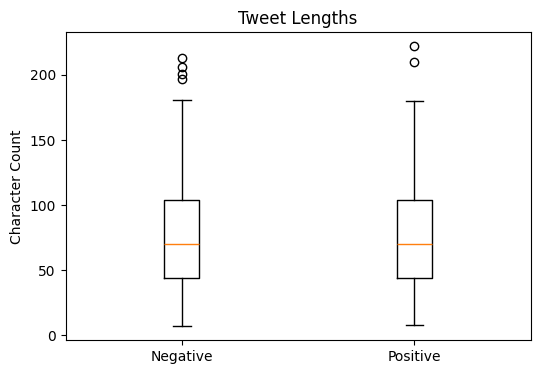

In [4]:
df_len = compute_tweet_lengths(df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([df_len[df_len['label'] == 'Negative']['length'], df_len[df_len['label'] == 'Positive']['length']], labels=['Negative', 'Positive'])
ax.set_title('Tweet Lengths')
ax.set_ylabel('Character Count')
plt.show()

## 3. Log-Odds Ratio (Top Words)

In [5]:
lor_df = compute_log_odds_ratio(df, top_n=10)
print('Top 10 words per class by log-odds ratio:')
display(lor_df)

Top 10 words per class by log-odds ratio:


,word,log_odds,count_pos,count_neg,class
0,tweeteradder,3.257786,24,0,Positive
1,shaunjumpnow,3.129953,21,0,Positive
2,tweeterfollow,3.129953,21,0,Positive
3,woohoo,2.956681,36,1,Positive
4,andyhurleyday,2.872124,16,0,Positive
5,stunning,2.811499,15,0,Positive
6,cutie,2.677968,13,0,Positive
7,welcome,2.641600,188,13,Positive
8,congratulations,2.641600,53,3,Positive
9,followfriday,2.616599,78,5,Positive


## 4. Linguistic Features

In [6]:
metrics = compute_linguistic_features(df)
summary = summarize_linguistic_features(metrics)
display(summary)

,avg_punctuation,avg_caps_ratio,avg_exclamation_density,url_presence_rate,count
label,,,,,
Negative,3.7565,0.043,0.0398,0.0324,24986
Positive,4.2490,0.050,0.0646,0.0658,25014
